# 2장 실습 — 사과를 가르는 선을 기계가 찾게 하기

**PyTorch 판**

본문 2.2~2.7절과 2.13절을 코드로 따라간다.

먼저 **선을 직접 조정하는 규칙**(2.6절의 `조정 값 = 오차 × 입력값 × 학습률`)을
numpy로 손수 구현해서, 선이 실제로 움직이는 것을 본다.
그다음 **같은 일을 프레임워크에 맡긴다.** 두 결과가 같다는 것을 확인하는 것이
이 노트북의 목적이다.

> 세 판(Keras / TensorFlow / PyTorch)에서 **달라지는 셀은 §2.4와 §2.6뿐**이다.
> 나머지는 글자까지 같다. 무엇이 딥러닝이고 무엇이 라이브러리의 사정인지가
> 그 차이에서 드러난다.

## 2.0 준비

In [1]:
# 아무것도 설치되어 있지 않은 브라우저 환경에서도 이 셀 하나면 준비가 끝난다.
# Kaggle · JupyterHub · Colab 어디서 열어도 같다. 개인 노트북에는 아무것도 설치하지 않는다.
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '-', 'tensorflow': '-', 'torch': '2.14.0', 'keras_backend': '-'}


## 2.1 데이터 — 크기와 색깔

사과 하나마다 값이 둘이다. 크기와 색깔. 이 둘을 **특질**(feature)이라 부르고,
나란히 쓴 `[크기, 색깔]`을 **입력 벡터**라 부른다. 여기서는 2차원이다.

구분            개수  입력 shape
train        240  (2,)
val           80  (2,)
test          80  (2,)


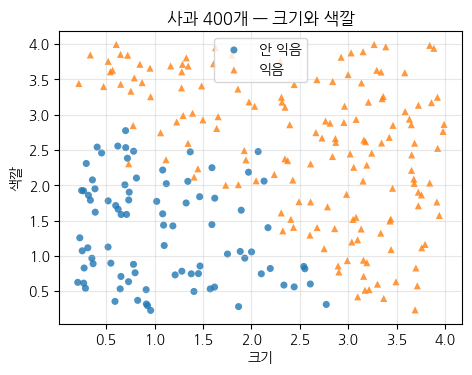

In [3]:
x, y = data.apples(n=400, seed=42)
s = data.split(x, y, val_ratio=0.2, test_ratio=0.2, seed=42)
print(s.summary())

plot.scatter2d(s.x_train, s.y_train, title="사과 400개 — 크기와 색깔")
plt.show()

## 2.2 손으로 그은 선

본문 2.5절에서 그은 선이 `x₁ + x₂ = 3.5` 였다.
그러니까 `w₁ = 1`, `w₂ = 1`, `b = -3.5` 인 셈이다.
이 선이 얼마나 맞히는지 세어 본다.

손으로 그은 선의 정확도: 0.95


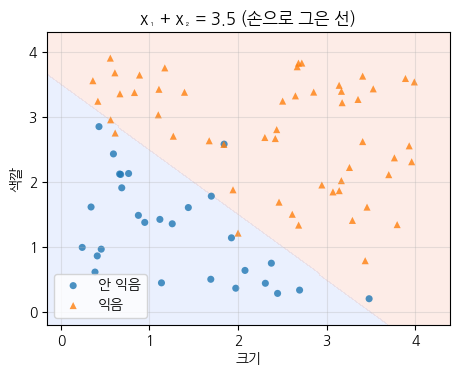

In [4]:
w_hand = np.array([1.0, 1.0])
b_hand = -3.5

def line_predict(g, w=w_hand, b=b_hand):
    return (g @ w + b > 0).astype("int64")

print("손으로 그은 선의 정확도:", metrics.accuracy(s.y_test, line_predict(s.x_test)))

plot.decision_boundary(line_predict, s.x_test, s.y_test,
                       title="x₁ + x₂ = 3.5 (손으로 그은 선)")
plt.show()

## 2.3 델타 규칙 — 선을 직접 조정한다

본문 2.6절의 규칙을 그대로 옮긴다.

```
조정 값 = 오차 × 입력값 × 학습률
```

오차가 0이면 조정도 0이다. **맞힌 것은 건드리지 않는다.**
프레임워크를 쓰지 않고 numpy만으로 쓴다. 세 판이 모두 이 셀을 공유한다.

찾은 선:  1.180·크기 + 1.267·색깔 + (-3.800) = 0
ch02_delta_test_acc = 0.9500


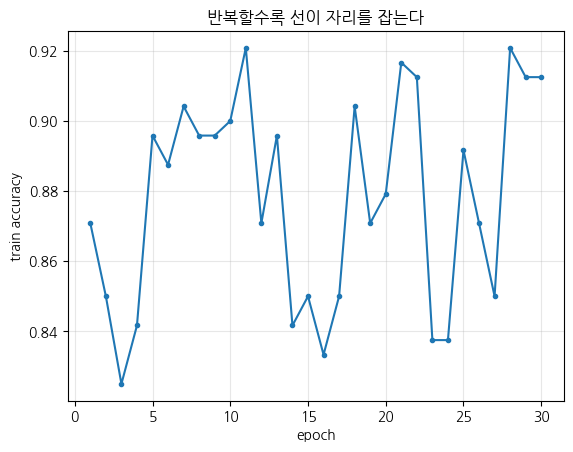

In [5]:
def delta_rule(x, y, lr=0.1, epochs=30, seed=0):
    """본문 2.6절의 규칙 그대로. 프레임워크를 쓰지 않는다."""
    rng = np.random.default_rng(seed)
    w = rng.normal(0, 0.5, size=x.shape[1])
    b = 0.0
    history = []
    for _ in range(epochs):
        for xi, yi in zip(x, y):
            pred = 1 if xi @ w + b > 0 else 0
            error = pred - yi                 # 틀린 방향
            w -= lr * error * xi              # 조정 값 = 오차 × 입력값 × 학습률
            b -= lr * error * 1.0             # b의 입력값은 늘 1이다
        history.append(metrics.accuracy(y, (x @ w + b > 0).astype(int)))
    return w, b, history

w_delta, b_delta, hist = delta_rule(s.x_train, s.y_train, lr=0.1, epochs=30)
print(f"찾은 선:  {w_delta[0]:.3f}·크기 + {w_delta[1]:.3f}·색깔 + ({b_delta:.3f}) = 0")
dlbook.record("ch02_delta_test_acc", metrics.accuracy(s.y_test,
              (s.x_test @ w_delta + b_delta > 0).astype(int)))

plt.plot(range(1, len(hist) + 1), hist, marker="o", ms=3)
plt.xlabel("epoch"); plt.ylabel("train accuracy"); plt.grid(alpha=0.3)
plt.title("반복할수록 선이 자리를 잡는다"); plt.show()

## 2.4 같은 일을 프레임워크에 맡긴다

여기부터가 판마다 다른 곳이다. 하는 일은 §2.3과 같다 —
가중치 두 개와 기준값 하나를 오차에 따라 조금씩 고친다.

In [6]:
import torch
from torch import nn

dlbook.set_seed(42)   # 프레임워크를 불러온 뒤 한 번 더. 그래야 이 판의 난수까지 고정된다

device = "cuda" if torch.cuda.is_available() else "cpu"

model = nn.Sequential(nn.Linear(2, 1)).to(device)   # 가중치 2개 + 기준값 1개
criterion = nn.BCEWithLogitsLoss()                  # 안쪽에서 sigmoid까지 한다
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
print(model, "/ device:", device)

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
) / device: cpu


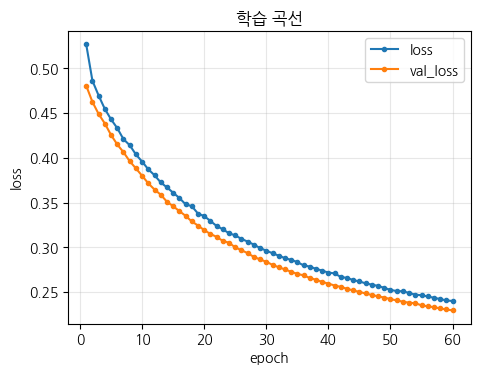

In [7]:
from torch.utils.data import DataLoader, TensorDataset

def as_ds(xa, ya):
    return TensorDataset(torch.tensor(xa, dtype=torch.float32),
                         torch.tensor(ya, dtype=torch.float32).view(-1, 1))

train_dl = DataLoader(as_ds(s.x_train, s.y_train), batch_size=16, shuffle=True)
xv = torch.tensor(s.x_val, dtype=torch.float32).to(device)
yv = torch.tensor(s.y_val, dtype=torch.float32).view(-1, 1).to(device)

history = {"loss": [], "val_loss": []}
for _ in range(dlbook.smoke.epochs(60)):
    model.train()
    losses = []
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()                       # 지난번 경사를 지우고
        loss = criterion(model(xb), yb)
        loss.backward()                             # 경사를 구하고
        optimizer.step()                            # 그 방향으로 내려간다
        losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        history["val_loss"].append(criterion(model(xv), yv).item())
    history["loss"].append(float(np.mean(losses)))

plot.loss_curve(history)
plt.show()

def fw_predict(g):
    model.eval()
    with torch.no_grad():
        logit = model(torch.tensor(np.asarray(g), dtype=torch.float32).to(device))
    return (logit.cpu().numpy().reshape(-1) > 0).astype("int64")

## 2.5 결과 — 손으로 한 것과 프레임워크가 한 것

두 방법이 비슷한 선을 그었는지 확인한다.
본문 2.6절 말미의 *"선형 모델에서는 경사하강의 결과가 앞의 직관적 방법과 동일하다"*
가 사실인지를 눈으로 보는 자리다.

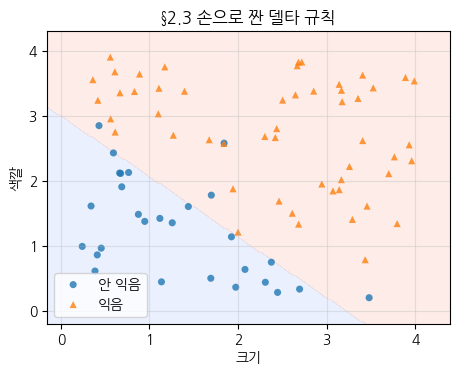

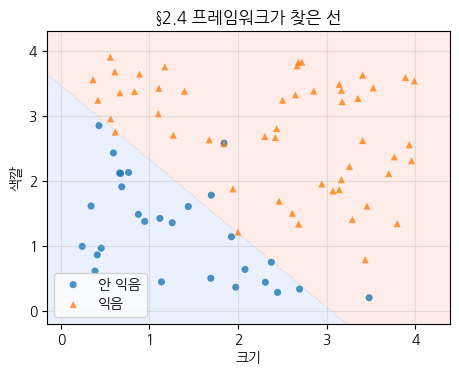

ch02_framework_test_acc = 0.9500
정확도  0.9500

혼동행렬 (행=실제, 열=예측)
        안 익음    익음
안 익음      25     3
익음         1    51

클래스         정밀도      재현율       F1     개수
안 익음      0.962    0.893    0.926     28
익음        0.944    0.981    0.962     52


In [8]:
plot.decision_boundary(lambda g: (g @ w_delta + b_delta > 0).astype(int),
                       s.x_test, s.y_test, title="§2.3 손으로 짠 델타 규칙")
plt.show()

plot.decision_boundary(fw_predict, s.x_test, s.y_test,
                       title="§2.4 프레임워크가 찾은 선")
plt.show()

acc_fw = metrics.accuracy(s.y_test, fw_predict(s.x_test))
dlbook.record("ch02_framework_test_acc", acc_fw)
print(metrics.report(s.y_test, fw_predict(s.x_test), ["안 익음", "익음"]))

## 2.6 선 하나로는 안 되는 문제 — XOR

본문 2.13절. 네 무리를 대각선끼리 묶어야 하는데, 직선 하나로는 절대 못 가른다.
먼저 **직선 하나로 해 보고 실패하는 것을 확인한 다음**, 은닉층을 넣는다.

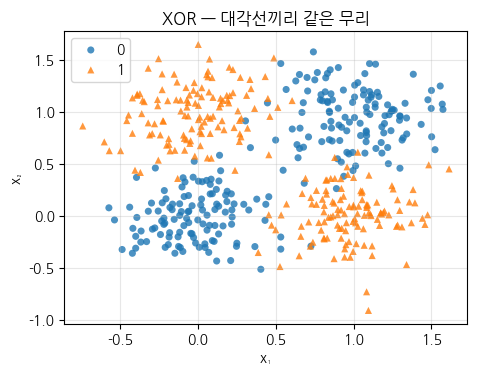

ch02_xor_single_line_acc = 0.5437
직선 하나의 정확도: 0.544 — 찍는 것과 다르지 않다


In [9]:
xx, yy = data.xor(n=800, seed=42)
sx = data.split(xx, yy, seed=42)
plot.scatter2d(sx.x_train, sx.y_train, class_names=("0", "1"),
               xlabel="x₁", ylabel="x₂", title="XOR — 대각선끼리 같은 무리")
plt.show()

# 먼저 직선 하나로. 델타 규칙을 그대로 돌린다.
w_x, b_x, _ = delta_rule(sx.x_train, sx.y_train, lr=0.1, epochs=50)
acc_line = metrics.accuracy(sx.y_test, (sx.x_test @ w_x + b_x > 0).astype(int))
dlbook.record("ch02_xor_single_line_acc", acc_line)
print("직선 하나의 정확도:", round(acc_line, 3), "— 찍는 것과 다르지 않다")

ch02_xor_hidden_acc = 0.9563


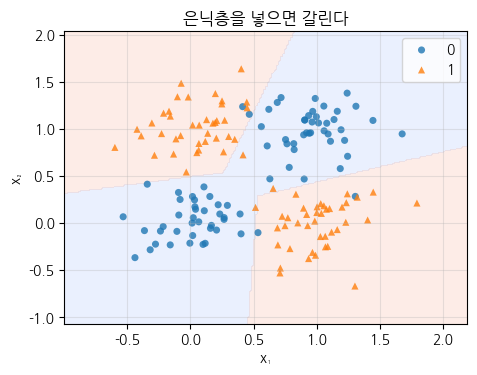

In [10]:
xor_model = nn.Sequential(
    nn.Linear(2, 8),
    nn.ReLU(),                                      # 은닉층. 활성화 함수가 핵심이다
    nn.Linear(8, 1),
).to(device)
xor_opt = torch.optim.Adam(xor_model.parameters(), lr=0.01)
xor_dl = DataLoader(as_ds(sx.x_train, sx.y_train), batch_size=32, shuffle=True)

for _ in range(dlbook.smoke.epochs(200)):
    xor_model.train()
    for xb, yb in xor_dl:
        xb, yb = xb.to(device), yb.to(device)
        xor_opt.zero_grad()
        criterion(xor_model(xb), yb).backward()
        xor_opt.step()

def xor_predict(g):
    xor_model.eval()
    with torch.no_grad():
        logit = xor_model(torch.tensor(np.asarray(g), dtype=torch.float32).to(device))
    return (logit.cpu().numpy().reshape(-1) > 0).astype("int64")

dlbook.record("ch02_xor_hidden_acc", metrics.accuracy(sx.y_test, xor_predict(sx.x_test)))
plot.decision_boundary(xor_predict, sx.x_test, sx.y_test, class_names=("0", "1"),
                       xlabel="x₁", ylabel="x₂", title="은닉층을 넣으면 갈린다")
plt.show()

## 정리

- 기준을 스스로 찾아가는 반복, 그것을 **학습**이라 부른다.
- 조정량은 `오차 × 입력값 × 학습률`. 오차가 0이면 조정도 0이다.
- 손으로 짠 규칙과 프레임워크의 경사하강이 **선형 모델에서는 같은 답**에 이른다.
- 직선 하나로 못 가르는 문제가 있다. 층을 쌓고 **비선형 활성화 함수**를 넣어야 갈린다.
  활성화 함수를 빼면 층을 아무리 쌓아도 여전히 직선 하나다 — 본문 2.13절.

### 연습

1. `noise` 를 0.6으로 올리면 정확도가 어떻게 되는가. 왜 그런가.
2. 학습률을 0.001과 1.0으로 바꿔 보라. 각각 무슨 일이 일어나는가.
3. §2.6의 은닉층 모델에서 **활성화 함수를 없애면** 정확도가 얼마가 되는가.
   그 값이 §2.6 앞부분의 '직선 하나' 결과와 같은 이유를 설명하라.